## 1. EDA (Eksplorasi Data)

Load Data

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Sales - Marketing customer dataset.csv')

print("--- 5 Baris Pertama ---")
print(df.head())

print("\n--- Informasi Dataset ---")
print(df.info())

print("\n--- Statistik Deskriptif ---")
print(df.describe(include='all'))

--- 5 Baris Pertama ---
   customer_id  gender   age  country     city          signup_date  \
0        10001    Male  52.0    India   Berlin  2022-05-10 00:00:00   
1        10002     NaN  35.0  Germany   Mumbai  2024-06-16 00:00:00   
2        10003  Female  27.0  Germany   London  2023-08-23 00:00:00   
3        10004  Female  36.0    India   Mumbai  2024-01-28 00:00:00   
4        10005    Male  29.0      USA  Hamburg  2023-07-21 00:00:00   

    last_purchase_date acquisition_channel device_type subscription_type  ...  \
0  2024-12-31 00:00:00               Email      Tablet            Annual  ...   
1  2024-05-07 00:00:00             Organic     Desktop           Monthly  ...   
2  2024-04-28 00:00:00               Email      Mobile            Annual  ...   
3  2023-05-20 00:00:00        Facebook Ads      Tablet            Annual  ...   
4  2024-04-07 00:00:00            Referral      Mobile           Monthly  ...   

   support_tickets  refund_requested  delivery_delay_days  pay

Cek & Visualisasi Missing Value

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16636\3895263358.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_val.values, y=missing_val.index, palette='viridis')


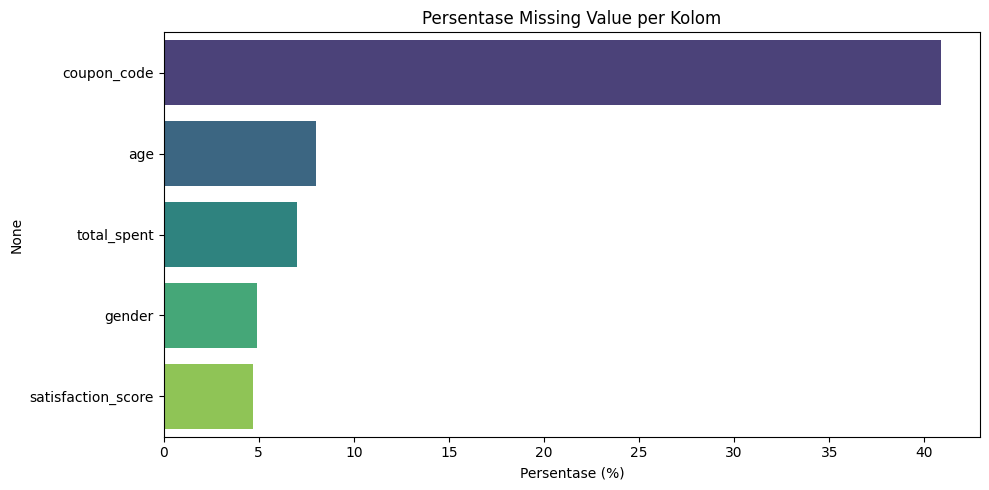

In [23]:
missing_val = df.isnull().sum() / len(df) * 100
missing_val = missing_val[missing_val > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
if not missing_val.empty:
    sns.barplot(x=missing_val.values, y=missing_val.index, palette='viridis')
    plt.title('Persentase Missing Value per Kolom')
    plt.xlabel('Persentase (%)')
else:
    plt.text(0.5, 0.5, 'Tidak ada missing value', ha='center', va='center')
    plt.title('Pengecekan Missing Value')
plt.tight_layout()
plt.show()

Distribusi Target Churn

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16636\2897773519.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='churn', palette='Set2')


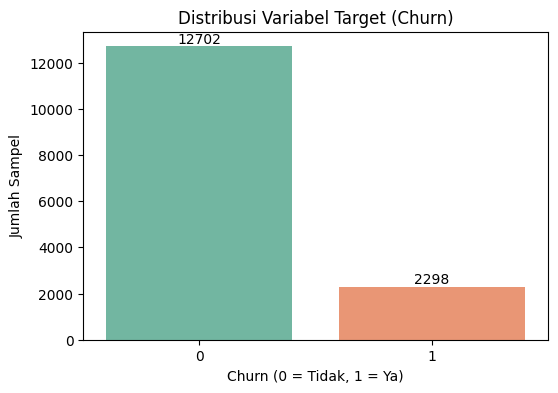

Proporsi Churn:
churn
0    84.68
1    15.32
Name: proportion, dtype: float64


In [24]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='churn', palette='Set2')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title('Distribusi Variabel Target (Churn)')
plt.xlabel('Churn (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Sampel')
plt.show()

print("Proporsi Churn:")
print(df['churn'].value_counts(normalize=True) * 100)

Heatmap Korelasi

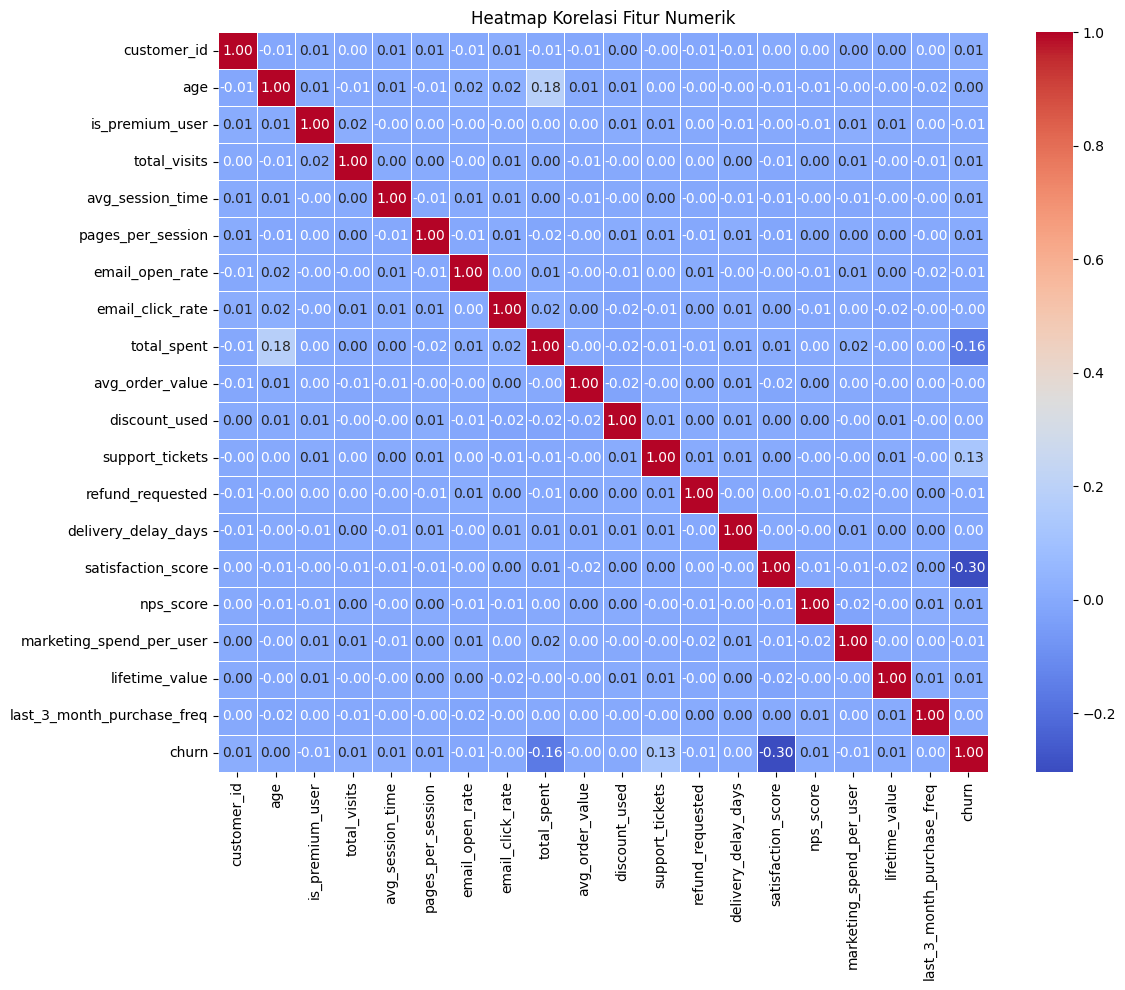

In [25]:
plt.figure(figsize=(12, 10))
numeric_cols_eda = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols_eda].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

## 2. Data Cleaning & Handling

Handling Missing Value, Duplikasi, Outlier

Jumlah duplikat dihapus: 0

Missing value setelah cleaning:
gender                 738
age                   1200
total_spent           1050
satisfaction_score     702
dtype: int64


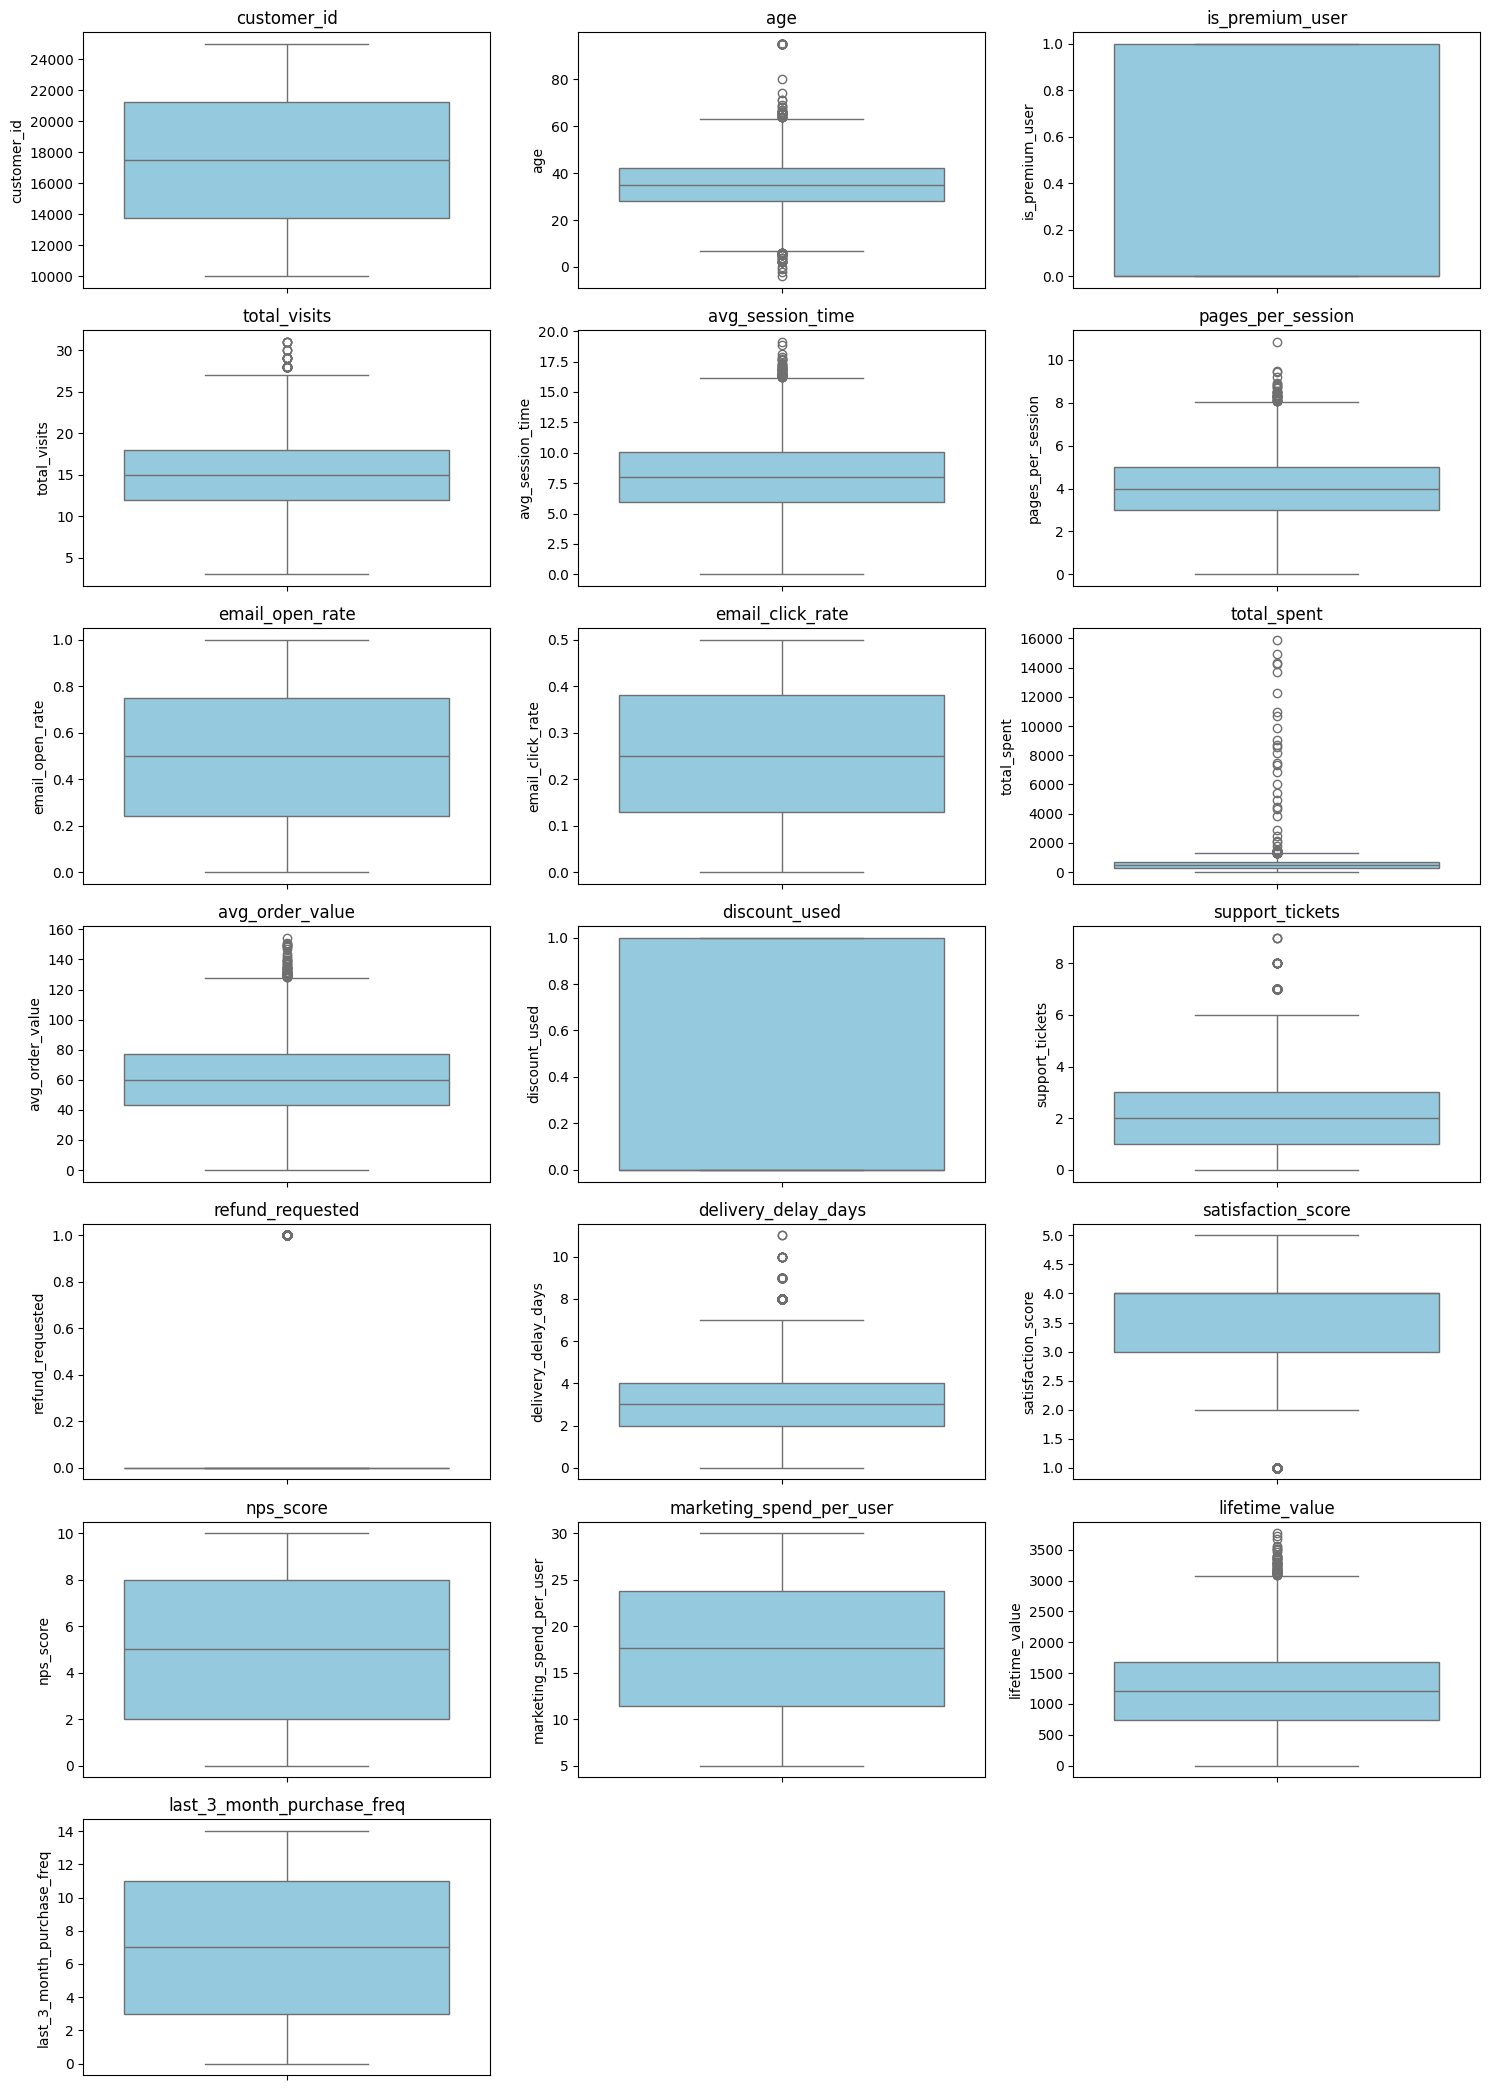

In [26]:
df_clean = df.copy()

# Hapus duplikasi
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Jumlah duplikat dihapus: {before - len(df_clean)}")

# Hapus kolom ID yang tidak relevan untuk modeling
df_clean = df_clean.drop(columns=['customer id', 'coupon_code'], errors='ignore')

# Cek ulang missing value setelah cleaning
print("\nMissing value setelah cleaning:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Visualisasi outlier pada fitur numerik (boxplot)
num_check = df_clean.select_dtypes(include=[np.number]).drop(columns=['churn'], errors='ignore').columns
n_cols = 3
n_rows = int(np.ceil(len(num_check) / n_cols))
plt.figure(figsize=(15, n_rows * 3))
for i, col in enumerate(num_check):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df_clean[col], color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

## 3. Feature Engineering

Membuat Fitur Baru

In [27]:
df_fe = df_clean.copy()

# Ubah kolom tanggal menjadi datetime
df_fe['signup_date'] = pd.to_datetime(df_fe['signup_date'], errors='coerce')
df_fe['last_purchase_date'] = pd.to_datetime(df_fe['last_purchase_date'], errors='coerce')

# Fitur 1: Lama berlangganan (tenure dalam hari)
df_fe['tenure_days'] = (df_fe['last_purchase_date'] - df_fe['signup_date']).dt.days

# Fitur 2: Recency - seberapa lama sejak transaksi terakhir (asumsi referensi tanggal max di data)
ref_date = df_fe['last_purchase_date'].max()
df_fe['recency_days'] = (ref_date - df_fe['last_purchase_date']).dt.days

# Fitur 3: Rata-rata nilai transaksi per kunjungan (jika kolom relevan tersedia)
if 'total_spend' in df_fe.columns and 'purchase_frequency' in df_fe.columns:
    df_fe['avg_spend_per_purchase'] = df_fe['total_spend'] / df_fe['purchase_frequency'].replace(0, np.nan)
    df_fe['avg_spend_per_purchase'] = df_fe['avg_spend_per_purchase'].fillna(0)

# Hapus kolom tanggal asli karena sudah direpresentasikan oleh fitur baru
df_fe = df_fe.drop(columns=['signup_date', 'last_purchase_date'], errors='ignore')

print("Fitur baru berhasil dibuat. Kolom saat ini:")
print(df_fe.columns.tolist())
df_fe[['tenure_days', 'recency_days']].describe()

Fitur baru berhasil dibuat. Kolom saat ini:
['customer_id', 'gender', 'age', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn', 'tenure_days', 'recency_days']


,tenure_days,recency_days
count,15000.000000,15000.000000
mean,264.791133,399.301867
std,369.240516,231.520502
min,-627.000000,0.000000
25%,-2.000000,197.000000
50%,266.000000,397.000000
75%,526.250000,602.000000
max,1157.000000,799.000000


Visualisasi Fitur Baru terhadap Churn

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16636\3901940845.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fe, x='churn', y='tenure_days', ax=axes[0], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16636\3901940845.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fe, x='churn', y='recency_days', ax=axes[1], palette='Set2')


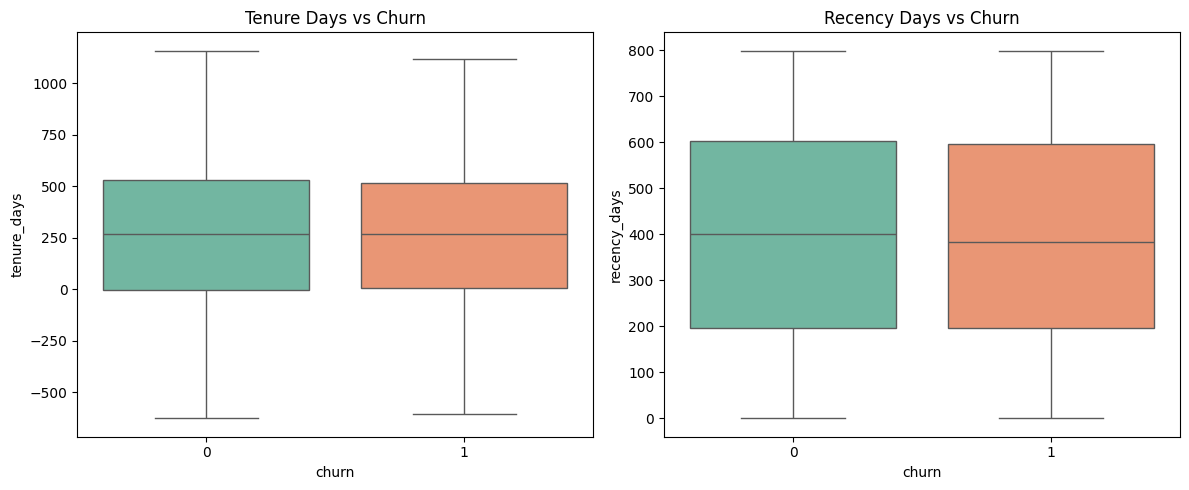

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_fe, x='churn', y='tenure_days', ax=axes[0], palette='Set2')
axes[0].set_title('Tenure Days vs Churn')

sns.boxplot(data=df_fe, x='churn', y='recency_days', ax=axes[1], palette='Set2')
axes[1].set_title('Recency Days vs Churn')
plt.tight_layout()
plt.show()

Helper Function untuk Mencatat Hasil Evaluasi

In [29]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

results_summary = []

def record_result(model_name, scenario, y_true, y_pred):
    metrics = {
        'Model': model_name,
        'Skenario': scenario,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }
    results_summary.append(metrics)
    print(f"\nModel: {model_name} | Skenario: {scenario}")
    print(f"Accuracy : {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall   : {metrics['Recall']:.4f}")
    print(f"F1-Score : {metrics['F1-Score']:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    return metrics

## 4. Direct Modeling (Tanpa Preprocessing)

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

drop_cols_direct = ['gender', 'country', 'city', 'acquisition_channel', 'device_type',
                     'subscription_type', 'payment_method']

df_direct = df_fe.drop(columns=drop_cols_direct, errors='ignore').dropna()

X_direct = df_direct.drop(columns=['churn'])
y_direct = df_direct['churn']

X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X_direct, y_direct, test_size=0.2, random_state=42, stratify=y_direct
)

# 3 Kategori Model
clf_konvensional = LogisticRegression(max_iter=1000, random_state=42)
clf_bagging = RandomForestClassifier(random_state=42)
clf_voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('svc', SVC(probability=True, random_state=42)),
        ('knn', KNeighborsClassifier())
    ],
    voting='soft'
)

models_direct = {
    'Logistic Regression (Konvensional)': clf_konvensional,
    'Random Forest (Bagging)': clf_bagging,
    'Voting Classifier - LR+SVC+KNN (Ensemble)': clf_voting
}

print("=== HASIL DIRECT MODELING ===")
for name, model in models_direct.items():
    model.fit(X_train_dir, y_train_dir)
    y_pred = model.predict(X_test_dir)
    record_result(name, 'Direct (Tanpa Preprocessing)', y_test_dir, y_pred)

=== HASIL DIRECT MODELING ===


c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Logistic Regression (Konvensional) | Skenario: Direct (Tanpa Preprocessing)
Accuracy : 0.8400
Precision: 0.4862
Recall   : 0.1362
F1-Score : 0.2129
Confusion Matrix:
[[2005   56]
 [ 336   53]]

Model: Random Forest (Bagging) | Skenario: Direct (Tanpa Preprocessing)
Accuracy : 0.8404
Precision: 0.4966
Recall   : 0.3753
F1-Score : 0.4275
Confusion Matrix:
[[1913  148]
 [ 243  146]]


c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Voting Classifier - LR+SVC+KNN (Ensemble) | Skenario: Direct (Tanpa Preprocessing)
Accuracy : 0.8416
Precision: 0.6000
Recall   : 0.0077
F1-Score : 0.0152
Confusion Matrix:
[[2059    2]
 [ 386    3]]


## 5. Preprocessing (Split, Imputasi, Encoding, Scaling)

Split Data

In [31]:
df_prep = df_fe.copy()
X_prep = df_prep.drop(columns=['churn'])
y_prep = df_prep['churn']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_prep, y_prep, test_size=0.2, random_state=42, stratify=y_prep
)

cat_cols = X_train_p.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train_p.select_dtypes(include=[np.number]).columns.tolist()

print("Kolom kategorikal:", cat_cols)
print("Kolom numerik:", num_cols)

Kolom kategorikal: ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'payment_method']
Kolom numerik: ['customer_id', 'age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'tenure_days', 'recency_days']


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16636\4129848331.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_p.select_dtypes(include=['object']).columns.tolist()


Imputasi Missing Value

In [32]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train_p[num_cols] = num_imputer.fit_transform(X_train_p[num_cols])
X_test_p[num_cols] = num_imputer.transform(X_test_p[num_cols])

X_train_p[cat_cols] = cat_imputer.fit_transform(X_train_p[cat_cols])
X_test_p[cat_cols] = cat_imputer.transform(X_test_p[cat_cols])

print("Imputasi selesai. Sisa missing value:", X_train_p.isnull().sum().sum())

Imputasi selesai. Sisa missing value: 0


Encoding Kategorikal

In [33]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat_encoded = encoder.fit_transform(X_train_p[cat_cols])
X_test_cat_encoded = encoder.transform(X_test_p[cat_cols])
encoded_cat_cols = encoder.get_feature_names_out(cat_cols)

print("Jumlah fitur hasil encoding:", len(encoded_cat_cols))

Jumlah fitur hasil encoding: 30


Scaling Numerik + Gabungkan

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_p[num_cols])
X_test_num_scaled = scaler.transform(X_test_p[num_cols])

X_train_final = np.hstack((X_train_num_scaled, X_train_cat_encoded))
X_test_final = np.hstack((X_test_num_scaled, X_test_cat_encoded))

all_features = num_cols + list(encoded_cat_cols)
print("Total fitur final:", X_train_final.shape[1])

Total fitur final: 51


## 6. Handling Imbalance Data dengan SMOTE

Cek Imbalance & Terapkan SMOTE

Distribusi kelas sebelum SMOTE:
churn
0    10162
1     1838
Name: count, dtype: int64

Distribusi kelas setelah SMOTE:
churn
1    10162
0    10162
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16636\522012312.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_p, ax=axes[0], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16636\522012312.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, ax=axes[1], palette='Set2')


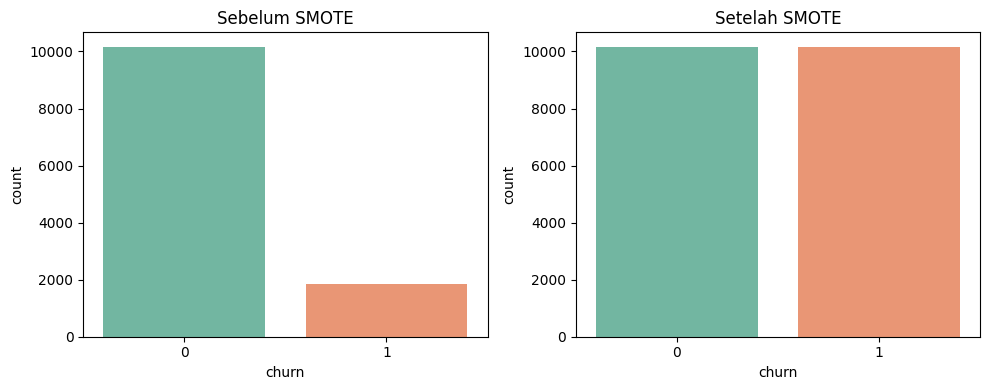

In [35]:
from imblearn.over_sampling import SMOTE

print("Distribusi kelas sebelum SMOTE:")
print(pd.Series(y_train_p).value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train_p)

print("\nDistribusi kelas setelah SMOTE:")
print(pd.Series(y_train_smote).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=y_train_p, ax=axes[0], palette='Set2')
axes[0].set_title('Sebelum SMOTE')
sns.countplot(x=y_train_smote, ax=axes[1], palette='Set2')
axes[1].set_title('Setelah SMOTE')
plt.tight_layout()
plt.show()

## 7. Modeling Dengan Preprocessing + SMOTE

In [36]:
clf1_p = LogisticRegression(max_iter=1000, random_state=42)
clf2_p = RandomForestClassifier(random_state=42)
clf3_p = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('svc', SVC(probability=True, random_state=42)),
        ('knn', KNeighborsClassifier())
    ],
    voting='soft'
)

models_prep = {
    'Logistic Regression (Konvensional)': clf1_p,
    'Random Forest (Bagging)': clf2_p,
    'Voting Classifier - LR+SVC+KNN (Ensemble)': clf3_p
}

print("=== HASIL MODELING DENGAN PREPROCESSING + SMOTE ===")
for name, model in models_prep.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_final)
    record_result(name, 'Preprocessing + SMOTE', y_test_p, y_pred)

=== HASIL MODELING DENGAN PREPROCESSING + SMOTE ===

Model: Logistic Regression (Konvensional) | Skenario: Preprocessing + SMOTE
Accuracy : 0.7597
Precision: 0.3607
Recall   : 0.7348
F1-Score : 0.4839
Confusion Matrix:
[[1941  599]
 [ 122  338]]

Model: Random Forest (Bagging) | Skenario: Preprocessing + SMOTE
Accuracy : 0.8507
Precision: 0.5140
Recall   : 0.4804
F1-Score : 0.4966
Confusion Matrix:
[[2331  209]
 [ 239  221]]

Model: Voting Classifier - LR+SVC+KNN (Ensemble) | Skenario: Preprocessing + SMOTE
Accuracy : 0.8107
Precision: 0.4260
Recall   : 0.6761
F1-Score : 0.5227
Confusion Matrix:
[[2121  419]
 [ 149  311]]


## 8. Feature Importance

Visualisasi Feature Importance

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16636\2576665366.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:top_n],


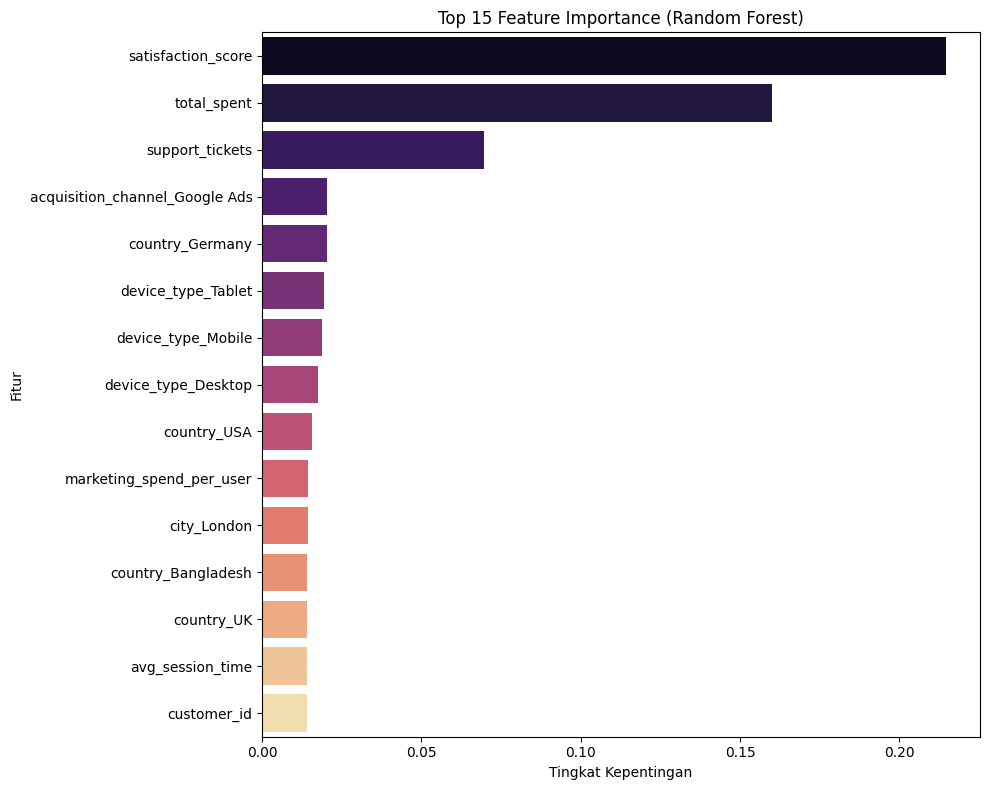


--- Top 5 Fitur Paling Berpengaruh ---
1. satisfaction_score (21.46%)
2. total_spent (16.00%)
3. support_tickets (6.97%)
4. acquisition_channel_Google Ads (2.03%)
5. country_Germany (2.02%)


In [37]:
importances = clf2_p.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 15

plt.figure(figsize=(10, 8))
sns.barplot(x=importances[indices][:top_n],
            y=np.array(all_features)[indices][:top_n],
            palette='magma')
plt.title(f'Top {top_n} Feature Importance (Random Forest)')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

print("\n--- Top 5 Fitur Paling Berpengaruh ---")
for f in range(5):
    print(f"{f + 1}. {all_features[indices[f]]} ({importances[indices[f]]*100:.2f}%)")

## 9. Hyperparameter Tuning (GridSearchCV)

GridSearchCV pada Data Hasil SMOTE

In [38]:
from sklearn.model_selection import GridSearchCV

# --- Tuning Logistic Regression (Konvensional) ---
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs']
}
print("Tuning Logistic Regression...")
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                        param_grid_lr, cv=3, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train_smote, y_train_smote)
best_lr_model = grid_lr.best_estimator_
print(f"Best Params LR: {grid_lr.best_params_}")

# --- Tuning Random Forest (Bagging) ---
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
print("\nTuning Random Forest...")
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                        param_grid_rf, cv=3, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train_smote, y_train_smote)
best_rf_model = grid_rf.best_estimator_
print(f"Best Params RF: {grid_rf.best_params_}")

# --- Tuning Voting Classifier (Ensemble LR+SVC+KNN) ---
# Catatan: tuning SVC dengan GridSearchCV bisa lambat untuk data besar,
# grid dibuat kecil supaya tetap berjalan dalam waktu wajar.
param_grid_voting = {
    'lr__C': [0.1, 1],
    'svc__C': [0.1, 1],
    'knn__n_neighbors': [3, 5]
}
voting_base = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('svc', SVC(probability=True, random_state=42)),
        ('knn', KNeighborsClassifier())
    ],
    voting='soft'
)
print("\nTuning Voting Classifier... (paling lama, mohon tunggu)")
grid_voting = GridSearchCV(voting_base, param_grid_voting, cv=3, scoring='f1', n_jobs=-1)
grid_voting.fit(X_train_smote, y_train_smote)
best_voting_model = grid_voting.best_estimator_
print(f"Best Params Voting: {grid_voting.best_params_}")

Tuning Logistic Regression...
Best Params LR: {'C': 0.1, 'solver': 'lbfgs'}

Tuning Random Forest...
Best Params RF: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

Tuning Voting Classifier... (paling lama, mohon tunggu)
Best Params Voting: {'knn__n_neighbors': 3, 'lr__C': 0.1, 'svc__C': 1}


## 10. Evaluasi Model Optimal & Penyimpanan Model

=== HASIL MODEL HASIL HYPERPARAMETER TUNING ===

Model: Logistic Regression (Konvensional) - Tuned | Skenario: Hyperparameter Tuning
Accuracy : 0.7590
Precision: 0.3603
Recall   : 0.7370
F1-Score : 0.4839
Confusion Matrix:
[[1938  602]
 [ 121  339]]


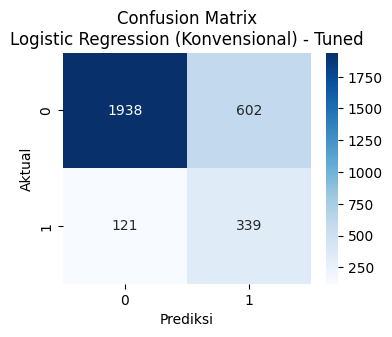


Model: Random Forest (Bagging) - Tuned | Skenario: Hyperparameter Tuning
Accuracy : 0.8503
Precision: 0.5087
Recall   : 0.7000
F1-Score : 0.5892
Confusion Matrix:
[[2229  311]
 [ 138  322]]


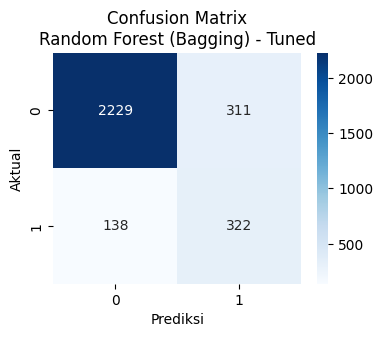


Model: Voting Classifier - LR+SVC+KNN (Ensemble) - Tuned | Skenario: Hyperparameter Tuning
Accuracy : 0.8070
Precision: 0.4163
Recall   : 0.6435
F1-Score : 0.5056
Confusion Matrix:
[[2125  415]
 [ 164  296]]


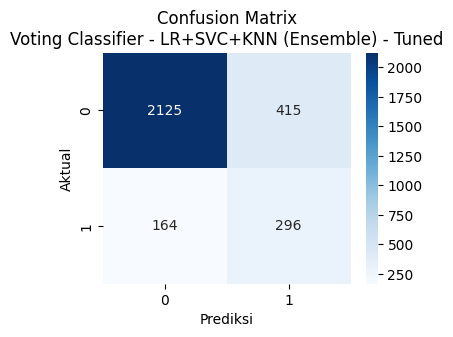

In [39]:
tuned_models = {
    'Logistic Regression (Konvensional) - Tuned': best_lr_model,
    'Random Forest (Bagging) - Tuned': best_rf_model,
    'Voting Classifier - LR+SVC+KNN (Ensemble) - Tuned': best_voting_model
}

print("=== HASIL MODEL HASIL HYPERPARAMETER TUNING ===")
for name, model in tuned_models.items():
    y_pred_opt = model.predict(X_test_final)
    record_result(name, 'Hyperparameter Tuning', y_test_p, y_pred_opt)

    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_test_p, y_pred_opt), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix\n{name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

## 11. Rekap & Perbandingan 9 Model

=== REKAP SELURUH 9 MODEL ===


,Model,Skenario,Accuracy,Precision,Recall,F1-Score
0,Random Forest (Bagging) - Tuned,Hyperparameter Tuning,0.850333,0.508689,0.700000,0.589204
1,Voting Classifier - LR+SVC+KNN (Ensemble),Preprocessing + SMOTE,0.810667,0.426027,0.676087,0.522689
2,Voting Classifier - LR+SVC+KNN (Ensemble) - Tuned,Hyperparameter Tuning,0.807000,0.416315,0.643478,0.505551
3,Random Forest (Bagging),Preprocessing + SMOTE,0.850667,0.513953,0.480435,0.496629
4,Logistic Regression (Konvensional) - Tuned,Hyperparameter Tuning,0.759000,0.360255,0.736957,0.483940
5,Logistic Regression (Konvensional),Preprocessing + SMOTE,0.759667,0.360726,0.734783,0.483894
6,Random Forest (Bagging),Direct (Tanpa Preprocessing),0.840408,0.496599,0.375321,0.427526
7,Logistic Regression (Konvensional),Direct (Tanpa Preprocessing),0.840000,0.486239,0.136247,0.212851
8,Voting Classifier - LR+SVC+KNN (Ensemble),Direct (Tanpa Preprocessing),0.841633,0.600000,0.007712,0.015228


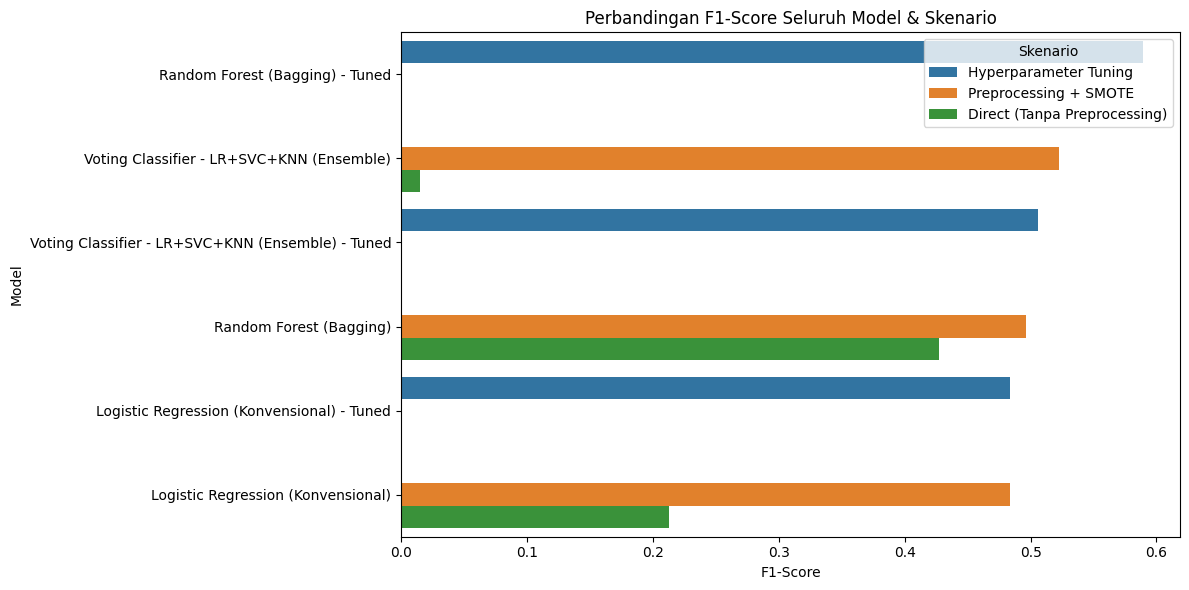


Model terbaik: Random Forest (Bagging) - Tuned | Skenario: Hyperparameter Tuning | F1-Score: 0.5892


In [40]:
results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("=== REKAP SELURUH 9 MODEL ===")
display(results_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='F1-Score', y='Model', hue='Skenario')
plt.title('Perbandingan F1-Score Seluruh Model & Skenario')
plt.tight_layout()
plt.show()

best_row = results_df.iloc[0]
print(f"\nModel terbaik: {best_row['Model']} | Skenario: {best_row['Skenario']} | F1-Score: {best_row['F1-Score']:.4f}")

In [41]:
import joblib

# Tentukan model terbaik secara otomatis berdasarkan F1-Score tertinggi pada skenario tuning
final_model_map = {
    'Logistic Regression (Konvensional) - Tuned': best_lr_model,
    'Random Forest (Bagging) - Tuned': best_rf_model,
    'Voting Classifier - LR+SVC+KNN (Ensemble) - Tuned': best_voting_model
}

best_model_name = best_row['Model']
final_model = final_model_map.get(best_model_name, best_rf_model)

joblib.dump(final_model, 'best_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoder, 'encoder.pkl')
joblib.dump(num_imputer, 'num_imputer.pkl')
joblib.dump(cat_imputer, 'cat_imputer.pkl')
joblib.dump(num_cols, 'num_cols.pkl')
joblib.dump(cat_cols, 'cat_cols.pkl')

print(f"Model terbaik ({best_model_name}) dan seluruh komponen preprocessing berhasil disimpan!")

Model terbaik (Random Forest (Bagging) - Tuned) dan seluruh komponen preprocessing berhasil disimpan!
